In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import folium
from folium.plugins import HeatMap

In [3]:
traffic_df = pd.read_csv('data/Traffic_Crashes.csv')
red_light_df = pd.read_csv('data/Red_Light.csv')
#clean all dataframes by long and lattitude
upper_left_lat = 41.954500 #W Irving Park Rd
upper_left_lon = -87.745480 #Cicero Ave
lower_right_lat = 41.765300 #71st St
lower_right_lon = -87.550018 #Lake Michigan


def clean_dataframe(df):
    df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])
    df = df[(df['LATITUDE'] >= lower_right_lat) & (df['LATITUDE'] <= upper_left_lat) &
            (df['LONGITUDE'] >= upper_left_lon) & (df['LONGITUDE'] <= lower_right_lon)]
    return df

#drop rows with missing values in INJURIES_TOTAL and filter for relevant traffic control devices that indicate intersections
traffic_df = clean_dataframe(traffic_df)
traffic_df = traffic_df.dropna(subset=['INJURIES_TOTAL'])
traffic_df = traffic_df[traffic_df['TRAFFIC_CONTROL_DEVICE'].isin(['FLASHING CONTROL SIGNAL', 'TRAFFIC SIGNAL'])]

red_light_df = clean_dataframe(red_light_df)

C:\Users\jessi\AppData\Local\Temp\ipykernel_4776\809174387.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  traffic_df = pd.read_csv('data/Traffic_Crashes.csv')


In [4]:
#write cleaned dataframes to new csv files
traffic_df.to_csv('data/cleaned_Traffic_Crashes.csv', index=False)
red_light_df.to_csv('data/cleaned_Red_Light.csv', index=False)

In [5]:
from sklearn.neighbors import BallTree

red_light_df = red_light_df.reset_index(drop=True)
red_light_df['red_light_id'] = np.arange(1, len(red_light_df) + 1)

# convert to radians for haversine distance
traffic_rad = np.radians(traffic_df[['LATITUDE', 'LONGITUDE']].values)
red_rad = np.radians(red_light_df[['LATITUDE', 'LONGITUDE']].values)

# build spatial index on red light cameras
tree = BallTree(red_rad, metric='haversine')

# find nearest red light camera for each crash
dist, ind = tree.query(traffic_rad, k=1)
traffic_df['dist_to_red_light_m'] = dist[:, 0] * 6371000  # Earth radius in meters

# threshold = 50 meters for "near" a red light camera
threshold = 50

# create binary indicator
traffic_df['has_red_light'] = (traffic_df['dist_to_red_light_m'] <= threshold).astype(int)
traffic_df['matched_red_light_id'] = red_light_df.iloc[ind[:, 0]]['red_light_id'].values


traffic_matched_df = traffic_df.copy()
cols_to_keep = [
    'CRASH_RECORD_ID',
    'CRASH_DATE',
    'POSTED_SPEED_LIMIT',
    'INJURIES_TOTAL',
    'INJURIES_FATAL',
    'INJURIES_INCAPACITATING',
    'INJURIES_NON_INCAPACITATING',
    'INJURIES_REPORTED_NOT_EVIDENT',
    'INJURIES_NO_INDICATION',
    'INJURIES_UNKNOWN',
    'LATITUDE',
    'LONGITUDE',
    'dist_to_red_light_m',
    'has_red_light',
    'matched_red_light_id'
]

traffic_matched_df = traffic_matched_df[cols_to_keep]
traffic_matched_df.to_csv('data/crashes_camera.csv', index=False)

In [6]:
traffic_matched_df.head(5)

,CRASH_RECORD_ID,CRASH_DATE,POSTED_SPEED_LIMIT,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,LATITUDE,LONGITUDE,dist_to_red_light_m,has_red_light,matched_red_light_id
11,05a1ef7524fa337f7bc45d41817be4bdbba7778ea24851...,04/05/2026 09:40:00 PM,30,0.0,0.0,0.0,0.0,0.0,2.0,0.0,41.779949,-87.625290,23.308203,1,37
23,b9d5dbd867a7bb0eb762aafc7e9e6f97e7c86f0dbe1f98...,04/05/2026 07:28:00 PM,30,0.0,0.0,0.0,0.0,0.0,3.0,0.0,41.809237,-87.631867,1649.588022,0,39
29,88fadca28781059ae241289f924d438a5c7a40eaded94c...,04/05/2026 07:10:00 PM,30,1.0,0.0,0.0,1.0,0.0,1.0,0.0,41.864681,-87.646990,263.247700,0,162
30,4c7e39bbb7d7ded2a5c35b131018dc3a21a47e9fb761aa...,04/05/2026 07:00:00 PM,30,0.0,0.0,0.0,0.0,0.0,5.0,0.0,41.883289,-87.624549,563.102174,0,99
36,b06b883b457c74cb3ba49583be68cccac67fbb76cbf1a0...,04/05/2026 06:15:00 PM,30,2.0,0.0,0.0,2.0,0.0,3.0,0.0,41.867120,-87.645281,97.573644,0,92


         Injury Type  Camera %  No Camera %  Camera Count  No Camera Count
               Fatal  0.136093     0.110490            24              180
      Incapacitating  1.996031     2.155792           352             3512
  Non-Incapacitating 11.051885    11.301332          1949            18411
Reported/Not Evident  7.110859     7.358664          1254            11988
Chart saved to data/injury_severity_analysis.png


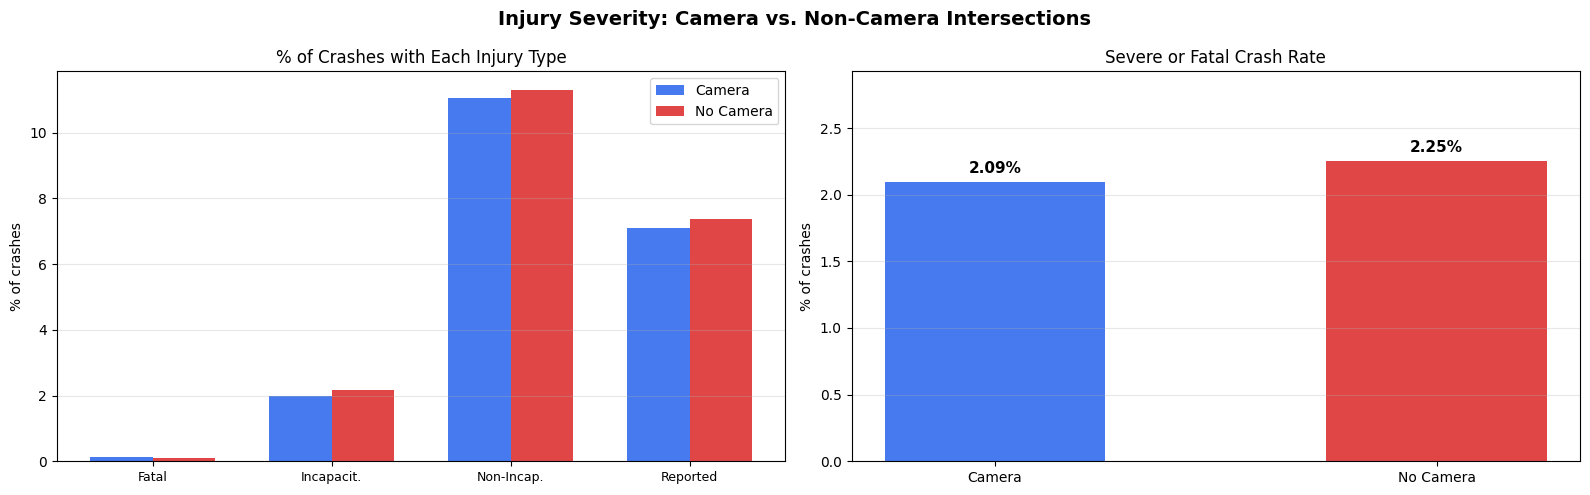

In [ ]:
cam    = traffic_matched_df[traffic_matched_df['has_red_light'] == 1]
no_cam = traffic_matched_df[traffic_matched_df['has_red_light'] == 0]

injury_cols = {
    'Fatal'               : 'INJURIES_FATAL',
    'Incapacitating'      : 'INJURIES_INCAPACITATING',
    'Non-Incapacitating'  : 'INJURIES_NON_INCAPACITATING',
    'Reported/Not Evident': 'INJURIES_REPORTED_NOT_EVIDENT',
}
rows = []
for label, col in injury_cols.items():
    rows.append({
        'Injury Type' : label,
        'Camera %'    : (cam[col] > 0).mean() * 100,
        'No Camera %' : (no_cam[col] > 0).mean() * 100,
        'Camera Count'    : (cam[col] > 0).sum(),
        'No Camera Count' : (no_cam[col] > 0).sum(),
    })
prop_df = pd.DataFrame(rows)
print(prop_df.to_string(index=False))

# % of crashes with any severe/fatal injury
traffic_matched_df['any_severe'] = ((traffic_matched_df['INJURIES_FATAL'] > 0) | (traffic_matched_df['INJURIES_INCAPACITATING'] > 0)).astype(int)
cam    = traffic_matched_df[traffic_matched_df['has_red_light'] == 1]
no_cam = traffic_matched_df[traffic_matched_df['has_red_light'] == 0]
cam_severe_pct   = cam['any_severe'].mean() * 100
nocam_severe_pct = no_cam['any_severe'].mean() * 100

BLUE, RED = '#2563EB', '#DC2626'
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Injury Severity: Camera vs. Non-Camera Intersections',
             fontsize=14, fontweight='bold')

# Plot 1 — % of crashes with each injury type
ax = axes[0]
x, w = np.arange(len(prop_df)), 0.35
ax.bar(x - w/2, prop_df['Camera %'],    w, label='Camera',    color=BLUE, alpha=0.85)
ax.bar(x + w/2, prop_df['No Camera %'], w, label='No Camera', color=RED,  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Fatal', 'Incapacit.', 'Non-Incap.', 'Reported'], fontsize=9)
ax.set_ylabel('% of crashes')
ax.set_title('% of Crashes with Each Injury Type')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2 — Severe/fatal crash rate
ax = axes[1]
rates = [cam_severe_pct, nocam_severe_pct]
bars  = ax.bar(['Camera', 'No Camera'], rates, color=[BLUE, RED], alpha=0.85, width=0.5)
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('% of crashes')
ax.set_title('Severe or Fatal Crash Rate')
ax.set_ylim(0, max(rates) * 1.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/injury_severity_analysis.png', dpi=150, bbox_inches='tight')
print("Chart saved to data/injury_severity_analysis.png")
plt.show()

In [ ]:
m = folium.Map(location=[41.85, -87.68], zoom_start=11)

heat_data = []

for _, row in traffic_matched_df.iterrows():
    lat = row['LATITUDE']
    lon = row['LONGITUDE']
    
    # weight based on severity
    weight = 0
    
    if row['INJURIES_FATAL'] > 0:
        weight = 3    
    elif row['INJURIES_INCAPACITATING'] > 0:
        weight = 2
    elif row['INJURIES_NON_INCAPACITATING'] > 0:
        weight = 1
    
    if weight > 0:
        heat_data.append([lat, lon, weight])

HeatMap(
    heat_data,
    radius=15,
    blur=15,
    max_zoom=15
).add_to(m)

for _, row in red_light_df.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=6,
        color='purple',
        fill=True,
        fill_opacity=0.7,
        popup="Red Light Camera"
    ).add_to(m)

m.save("crash_heatmap.html")

Map saved to crash_heatmap.html
